## Import the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load the dataset

In [2]:
df = pd.read_csv(r"naukri.csv")
df.head()

,company,education,experience,industry,jobdescription,jobid,joblocation_address,jobtitle,numberofpositions,payrate,postdate,site_name,skills,uniq_id
0,MM Media Pvt Ltd,UG: B.Tech/B.E. - Any Specialization PG:Any Po...,0 - 1 yrs,Media / Entertainment / Internet,Job Description Send me Jobs like this Quali...,210516002263,Chennai,Walkin Data Entry Operator (night Shift),NaN,"1,50,000 - 2,25,000 P.A",2016-05-21 19:30:00 +0000,NaN,ITES,43b19632647068535437c774b6ca6cf8
1,find live infotech,UG: B.Tech/B.E. - Any Specialization PG:MBA/PG...,0 - 0 yrs,Advertising / PR / MR / Event Management,Job Description Send me Jobs like this Quali...,210516002391,Chennai,Work Based Onhome Based Part Time.,60.0,"1,50,000 - 2,50,000 P.A. 20000",2016-05-21 19:30:00 +0000,NaN,Marketing,d4c72325e57f89f364812b5ed5a795f0
2,Softtech Career Infosystem Pvt. Ltd,UG: Any Graduate - Any Specialization PG:Any P...,4 - 8 yrs,IT-Software / Software Services,Job Description Send me Jobs like this - as ...,101016900534,Bengaluru,Pl/sql Developer - SQL,NaN,Not Disclosed by Recruiter,2016-10-13 16:20:55 +0000,NaN,IT Software - Application Programming,c47df6f4cfdf5b46f1fd713ba61b9eba
3,Onboard HRServices LLP,UG: Any Graduate - Any Specialization PG:CA Do...,11 - 15 yrs,Banking / Financial Services / Broking,Job Description Send me Jobs like this - Inv...,81016900536,"Mumbai, Bengaluru, Kolkata, Chennai, Coimbator...",Manager/ad/partner - Indirect Tax - CA,NaN,Not Disclosed by Recruiter,2016-10-13 16:20:55 +0000,NaN,Accounts,115d28f140f694dd1cc61c53d03c66ae
4,Spire Technologies and Solutions Pvt. Ltd.,UG: B.Tech/B.E. - Any Specialization PG:Any Po...,6 - 8 yrs,IT-Software / Software Services,Job Description Send me Jobs like this Pleas...,120916002122,Bengaluru,JAVA Technical Lead (6-8 yrs) -,4.0,Not Disclosed by Recruiter,2016-10-13 16:20:55 +0000,NaN,IT Software - Application Programming,a12553fc03bc7bcced8b1bb8963f97b4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              21996 non-null  object 
 1   education            20004 non-null  object 
 2   experience           21996 non-null  object 
 3   industry             21995 non-null  object 
 4   jobdescription       21996 non-null  object 
 5   jobid                22000 non-null  int64  
 6   joblocation_address  21499 non-null  object 
 7   jobtitle             22000 non-null  object 
 8   numberofpositions    4464 non-null   float64
 9   payrate              21903 non-null  object 
 10  postdate             21977 non-null  object 
 11  site_name            3987 non-null   object 
 12  skills               21472 non-null  object 
 13  uniq_id              22000 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 2.3+ MB


In [4]:
df.shape

(22000, 14)

## Checking for columns

In [5]:
df.columns

Index(['company', 'education', 'experience', 'industry', 'jobdescription',
       'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions',
       'payrate', 'postdate', 'site_name', 'skills', 'uniq_id'],
      dtype='object')

## Checking for missing values

In [6]:
df.isnull().sum()

company                    4
education               1996
experience                 4
industry                   5
jobdescription             4
jobid                      0
joblocation_address      501
jobtitle                   0
numberofpositions      17536
payrate                   97
postdate                  23
site_name              18013
skills                   528
uniq_id                    0
dtype: int64

## Replace the null values

In [7]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [8]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## Check after replacing 

In [9]:
df.isnull().sum()

company                0
education              0
experience             0
industry               0
jobdescription         0
jobid                  0
joblocation_address    0
jobtitle               0
numberofpositions      0
payrate                0
postdate               0
site_name              0
skills                 0
uniq_id                0
dtype: int64

## Statatical data looking

In [10]:
df.describe()

,jobid,numberofpositions
count,2.200000e+04,22000.000000
mean,1.561171e+11,45.116935
std,9.423956e+10,83.865840
min,1.011600e+10,1.000000
25%,6.121650e+10,45.116935
50%,1.602169e+11,45.116935
75%,2.502166e+11,45.116935
max,3.112155e+11,2000.000000


## Duplicates value

In [11]:
df.duplicated().sum()

np.int64(0)

## Visualize the numerica columns

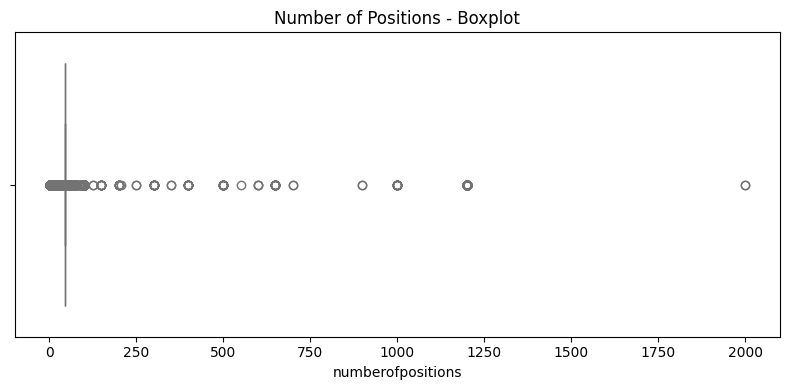

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['numberofpositions'], color='lightgreen')
plt.title('Number of Positions - Boxplot')
plt.tight_layout()
plt.show()

## finding outliers in numeric data

In [13]:
col = "numberofpositions"

Q1  = df[col].quantile(0.25)
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1

In [14]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [15]:
print(f"Q1          : {Q1}")
print(f"Q3          : {Q3}")
print(f"IQR         : {IQR}")
print(f"Lower Bound : {lower}")
print(f"Upper Bound : {upper}")


Q1          : 45.11693548387097
Q3          : 45.11693548387097
IQR         : 0.0
Lower Bound : 45.11693548387097
Upper Bound : 45.11693548387097


In [16]:
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f"Total Outliers : {len(outliers)}")

Total Outliers : 4464


## Removing of Outliers

In [17]:
df = df[(df['numberofpositions'] >= lower) & (df['numberofpositions'] <= upper)]

print("Rows after removing outliers:", len(df))



Rows after removing outliers: 17536


## Plot after removing outliers

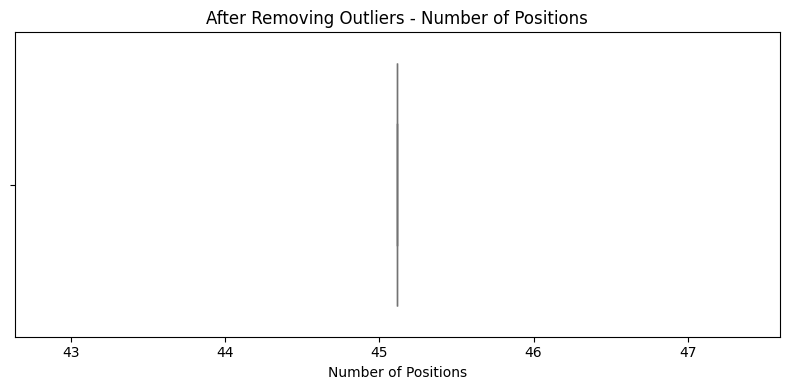

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['numberofpositions'], color='lightgreen')
plt.title('After Removing Outliers - Number of Positions')
plt.xlabel('Number of Positions')
plt.tight_layout()
plt.show()

## Unique value check 

In [19]:

for col in df.select_dtypes(include='object').columns:
    print(f"{col:20s} → {df[col].nunique()} unique values")


company              → 6160 unique values
education            → 1461 unique values
experience           → 142 unique values
industry             → 62 unique values
jobdescription       → 16701 unique values
joblocation_address  → 1651 unique values
jobtitle             → 13806 unique values
payrate              → 858 unique values
postdate             → 3734 unique values
site_name            → 1 unique values
skills               → 45 unique values
uniq_id              → 17536 unique values


## Cleaning data manually
 joblocation_address, education, Industry,skill...

### Joblocation_address column cleaning.

In [20]:
df['joblocation_address'] = df['joblocation_address'].str.split(',')
df['joblocation_address']

0                                                [Chennai]
2                                              [Bengaluru]
3        [Mumbai,  Bengaluru,  Kolkata,  Chennai,  Coim...
5                                              [Bengaluru]
9                                              [Bengaluru]
                               ...                        
21994                                [Bengaluru,  Chennai]
21996                                [Bengaluru,  Gurgaon]
21997                                          [Bengaluru]
21998                              [Delhi NCR,  Bengaluru]
21999                                          [Bengaluru]
Name: joblocation_address, Length: 17536, dtype: object

#### Clean the text and spaces

In [21]:

 df = df.explode('joblocation_address')

 pd.set_option('display.max_rows',5000)
 df['joblocation_address'].value_counts()

joblocation_address
Bengaluru/Bangalore                               3713
Mumbai                                            2351
Bengaluru/Bangalore                               1656
Bengaluru                                         1445
 Mumbai                                           1223
Hyderabad / Secunderabad                          1152
Mumbai                                             977
Hyderabad                                          712
Chennai                                            676
Noida                                              642
Delhi                                              639
Delhi                                              591
 Mumbai                                            584
Gurgaon                                            580
 Chennai                                           576
 Pune                                              529
 Chennai                                           517
 Delhi                                       

In [22]:
# ── Bangalore ────────────────────────────────────────────────────────────────
bangalore_map = {
    '(Bengaluru/Bangalore)': 'Bangalore',
    ' Bangalore': 'Bangalore',
    ' Bangalore ': 'Bangalore',
    'Bangalore ': 'Bangalore',
    'Bengaluru/Bangalore ': 'Bangalore',
    ' Bengaluru/Bangalore ': 'Bangalore',
    ' Bengaluru/Bangalore': 'Bangalore',
    'Bengaluru/Bangalore': 'Bangalore',
    'Bengaluru': 'Bangalore',
    'NCR Bangalore': 'Bangalore',
    'NCR Bangalore ': 'Bangalore',
    'Near Bangalore': 'Bangalore',
    ' Bengaluru/Bangalore': 'Bangalore',
    ' Bengaluru/Bangalore ': 'Bangalore',
    ' Bengaluru': 'Bangalore',
    'Bangalore , Bangalore / Bangalore': 'Bangalore',
    'Bangalore , karnataka': 'Bangalore',
    ' Bengaluru / Bangalore': 'Bangalore',
    ' Bengaluru / Bangalore ': 'Bangalore',
    'Bengaluru Bangalore': 'Bangalore',
    'India-Karnataka-Bangalore': 'Bangalore',
    ' bangalore': 'Bangalore',
    ' karnataka': 'Bangalore',
    ' Bengaluru Bangalore': 'Bangalore',
}
df['joblocation_address'] = df['joblocation_address'].replace(bangalore_map)

# ── NCR / Delhi ───────────────────────────────────────────────────────────────
ncr_map = {
    'Noida': 'NCR', 'Noida ': 'NCR', ' Noida': 'NCR', ' Noida ': 'NCR',
    ' noida': 'NCR', ' Noida/Greater Noida': 'NCR', ' Noida/Greater Noida ': 'NCR',
    'Noida , Noida/Greater Noida': 'NCR',
    ' Delhi': 'NCR', 'Delhi': 'NCR', 'Delhi ': 'NCR', ' Delhi ': 'NCR',
    ' Delhi NCR': 'NCR', 'Delhi NCR': 'NCR', ' Delhi/NCR': 'NCR', 'Delhi/NCR ': 'NCR',
    'Delhi , Delhi': 'NCR',
    'Delhi/NCR(National Capital Region)': 'NCR',
    'Delhi/NCR(National Capital Region) ': 'NCR',
    ' Delhi/NCR ': 'NCR',
    ' Delhi/NCR(National Capital Region)': 'NCR',
    ' Delhi/NCR(National Capital Region) ': 'NCR',
    'Delhi/NCR(National Capital Region) , Gurgaon': 'NCR',
    ' delhi': 'NCR',
    'Gurgaon': 'NCR', ' Gurgaon': 'NCR', ' Gurgaon ': 'NCR', 'Gurgaon ': 'NCR',
    'Ghaziabad': 'NCR', ' Ghaziabad': 'NCR', 'Ghaziabad ': 'NCR', ' Ghaziabad ': 'NCR',
    'Greater Noida': 'NCR', ' Greater Noida': 'NCR',
    ' Greater Noida ': 'NCR', 'Greater Noida ': 'NCR',
    'Faridabad': 'NCR', 'Faridabad ': 'NCR', ' Faridabad': 'NCR', ' Faridabad ': 'NCR',
    'NCR , NCR': 'NCR',
    'NCR/NCR(National Capital Region)': 'NCR',
    'NCR , NCR/Greater NCR': 'NCR',
    'NCR/NCR(National Capital Region), NCR': 'NCR',
    'NCR , NCR/NCR(National Capital Region)': 'NCR',
    'NCR/Greater NCR': 'NCR',
    'NCR/NCR(National Capital Region) , NCR': 'NCR',
}
df['joblocation_address'] = df['joblocation_address'].replace(ncr_map)

# ── Chennai ───────────────────────────────────────────────────────────────────
chennai_map = {
    'Chennai ': 'Chennai', ' Chennai': 'Chennai', ' Chennai ': 'Chennai',
    'chennai ': 'Chennai', ' chennai': 'Chennai', ' chennai ': 'Chennai', ' chennai': 'Chennai',
}
df['joblocation_address'] = df['joblocation_address'].replace(chennai_map)

# ── Single-city cleanups (strip extra spaces / case variants) ─────────────────
city_map = {
    # Pune
    'Pune ': 'Pune', ' Pune': 'Pune', ' Pune ': 'Pune',
    # Kolkata
    'Kolkata ': 'Kolkata', ' Kolkata': 'Kolkata', ' Kolkata ': 'Kolkata',
    ' kolkata': 'Kolkata', 'kolkata ': 'Kolkata',
    # Ahmedabad
    ' Ahmedabad': 'Ahmedabad', 'Ahmedabad ': 'Ahmedabad', ' Ahmedabad ': 'Ahmedabad',
    # Chandigarh
    'Chandigarh ': 'Chandigarh', ' Chandigarh': 'Chandigarh', ' Chandigarh ': 'Chandigarh',
    # Surat
    'Surat ': 'Surat', ' Surat': 'Surat', ' Surat ': 'Surat',
    # Kochi
    'Ernakulam / Kochi/ Cochin ': 'Kochi', ' Kochi': 'Kochi', 'Kochi ': 'Kochi',
    ' Kochi ': 'Kochi', ' Cochin/ Kochi/ Ernakulam': 'Kochi',
    ' Cochin/ Kochi/ Ernakulam ': 'Kochi', ' Ernakulam / Kochi/ Cochin': 'Kochi',
    ' Ernakulam / Kochi/ Cochin ': 'Kochi',
    # Coimbatore
    'Coimbatore ': 'Coimbatore', ' Coimbatore': 'Coimbatore', ' Coimbatore ': 'Coimbatore',
    # Lucknow
    'Lucknow ': 'Lucknow', ' Lucknow': 'Lucknow', ' Lucknow ': 'Lucknow',
    # Jaipur
    'Jaipur ': 'Jaipur', ' Jaipur': 'Jaipur', ' Jaipur ': 'Jaipur',
    'jaipur ': 'Jaipur', ' jaipur': 'Jaipur', ' jaipur ': 'Jaipur',
    # Vijayawada
    'Vijayawada ': 'Vijayawada', ' Vijayawada': 'Vijayawada', ' Vijayawada ': 'Vijayawada',
    # Visakhapatnam
    'Visakhapatnam ': 'Visakhapatnam', ' Visakhapatnam': 'Visakhapatnam',
    ' Visakhapatnam ': 'Visakhapatnam', 'Visakhapatnam/Vizag ': 'Visakhapatnam',
    ' Visakhapatnam/Vizag': 'Visakhapatnam', ' Visakhapatnam/Vizag ': 'Visakhapatnam',
    # Bhubaneshwar
    ' Bhubaneshwar': 'Bhubaneshwar', ' Bhubaneshwar ': 'Bhubaneshwar',
    # Patna
    ' Patna': 'Patna', ' Patna ': 'Patna',
    # Trivandrum
    ' Trivandrum': 'Trivandrum', ' Trivandrum ': 'Trivandrum',
    # Mangalore
    ' Mangalore': 'Mangalore', ' Mangalore ': 'Mangalore',
    # Indore
    ' Indore': 'Indore', ' Indore ': 'Indore',
    # Guwahati
    ' Guwahati': 'Guwahati', ' Guwahati ': 'Guwahati',
    # Nagpur
    ' Nagpur': 'Nagpur', ' Nagpur ': 'Nagpur',
    # Raipur
    ' Raipur': 'Raipur', ' Raipur ': 'Raipur',
    # Thane
    ' Thane': 'Thane', ' Thane ': 'Thane',
    # Bhopal
    ' Bhopal': 'Bhopal', ' Bhopal ': 'Bhopal',
    # Vadodara
    ' Vadodara/Baroda': 'Vadodara', ' Vadodara/Baroda ': 'Vadodara',
    ' Vadodara': 'Vadodara', 'Vadodara ': 'Vadodara', ' Vadodara ': 'Vadodara',
}
df['joblocation_address'] = df['joblocation_address'].replace(city_map)

# ── Final check ───────────────────────────────────────────────────────────────
pd.set_option('display.max_rows', 5000)   
df['joblocation_address'].value_counts()

joblocation_address
Bangalore                                         8456
NCR                                               6684
Mumbai                                            2351
Chennai                                           2037
 Mumbai                                           1223
Hyderabad / Secunderabad                          1152
Mumbai                                             977
Pune                                               834
Hyderabad                                          712
 Mumbai                                            584
 Hyderabad / Secunderabad                          364
 Hyderabad                                         359
 Hyderabad / Secunderabad                          317
Kolkata                                            315
Ahmedabad                                          241
Hyderabad / Secunderabad                           192
Chandigarh                                         122
 Hyderabad/Secunderabad                      

In [23]:
counts = df['joblocation_address'].value_counts()
df = df[df['joblocation_address'].isin(counts.index[counts>25])]

In [24]:
df['joblocation_address'].value_counts()

joblocation_address
Bangalore                     8456
NCR                           6684
Mumbai                        2351
Chennai                       2037
 Mumbai                       1223
Hyderabad / Secunderabad      1152
Mumbai                         977
Pune                           834
Hyderabad                      712
 Mumbai                        584
 Hyderabad / Secunderabad      364
 Hyderabad                     359
 Hyderabad / Secunderabad      317
Kolkata                        315
Ahmedabad                      241
Hyderabad / Secunderabad       192
Chandigarh                     122
 Hyderabad/Secunderabad        115
Jaipur                         106
 Hyderabad/Secunderabad         95
Coimbatore                      95
 Navi Mumbai                    81
Visakhapatnam                   69
Lucknow                         68
Bhubaneshwar                    59
Vadodara                        57
Kochi                           57
 maharashtra                    46


## cleaning experince

In [25]:
df['experience']

0          0 - 1 yrs
2          4 - 8 yrs
3        11 - 15 yrs
3        11 - 15 yrs
3        11 - 15 yrs
            ...     
21996      3 - 5 yrs
21997      2 - 4 yrs
21998     7 - 12 yrs
21998     7 - 12 yrs
21999     5 - 10 yrs
Name: experience, Length: 28234, dtype: object

In [26]:
# Step 1: Remove ' yrs' suffix
# EXPLANATION: str.replace() removes the text, strip() removes extra spaces
df['experience'] = df['experience'].str.replace(' yrs', '', regex=False)
df['experience'] = df['experience'].str.strip()

print("After removing 'yrs':")
print(df['experience'].unique()[:10])

After removing 'yrs':
['0 - 1' '4 - 8' '11 - 15' '2 - 5' '1 - 5' '1 - 3' '3 - 8' '2 - 4'
 '5 - 10' '6 - 10']


In [27]:
df['experience'] = df['experience'].str.split(" ")
df['Min Experience'] = df['experience'].apply(lambda x: x[0])
df['Max Experience'] = df['experience'].apply(lambda x: x[2] if len(x) > 2 else x[1])


In [28]:
df['Min Experience'].value_counts()

Min Experience
2      6372
3      4521
1      3352
0      3158
5      2804
4      2617
6      1246
10     1159
8      1067
7       869
12      263
15      240
9       209
Not     111
11       74
13       61
14       58
20       17
16       16
18       13
17        5
25        1
26        1
Name: count, dtype: int64

In [29]:
df['Max Experience'].value_counts()

Max Experience
5            4861
7            3860
8            3029
6            2657
10           2398
3            2139
4            2001
9            1493
2            1197
12            847
15            704
11            635
13            592
1             491
20            378
14            196
0             159
18            112
Mentioned     111
16             83
17             80
22             75
25             54
23             23
19             23
24             14
21             12
30              7
-1              1
26              1
28              1
Name: count, dtype: int64

In [30]:
df['Min Experience'] = df['Min Experience'].replace('Not', 0)
df['Max Experience'] = df['Max Experience'].replace(('Mentioned','-1'),(5,5))

In [31]:
df['Max Experience'].value_counts()

Max Experience
5     4861
7     3860
8     3029
6     2657
10    2398
3     2139
4     2001
9     1493
2     1197
12     847
15     704
11     635
13     592
1      491
20     378
14     196
0      159
18     112
5      112
16      83
17      80
22      75
25      54
23      23
19      23
24      14
21      12
30       7
26       1
28       1
Name: count, dtype: int64

In [32]:
df['Min Experience'] = df['Min Experience'].astype(int)
df['Max Experience'] = df['Max Experience'].astype(int)

print(df['Min Experience'].dtype)
print(df['Max Experience'].dtype)
df[['Min Experience', 'Max Experience']].head(10)

int64
int64


,Min Experience,Max Experience
0,0,1
2,4,8
3,11,15
3,11,15
3,11,15
3,11,15
3,11,15
5,2,5
9,1,5
10,1,3


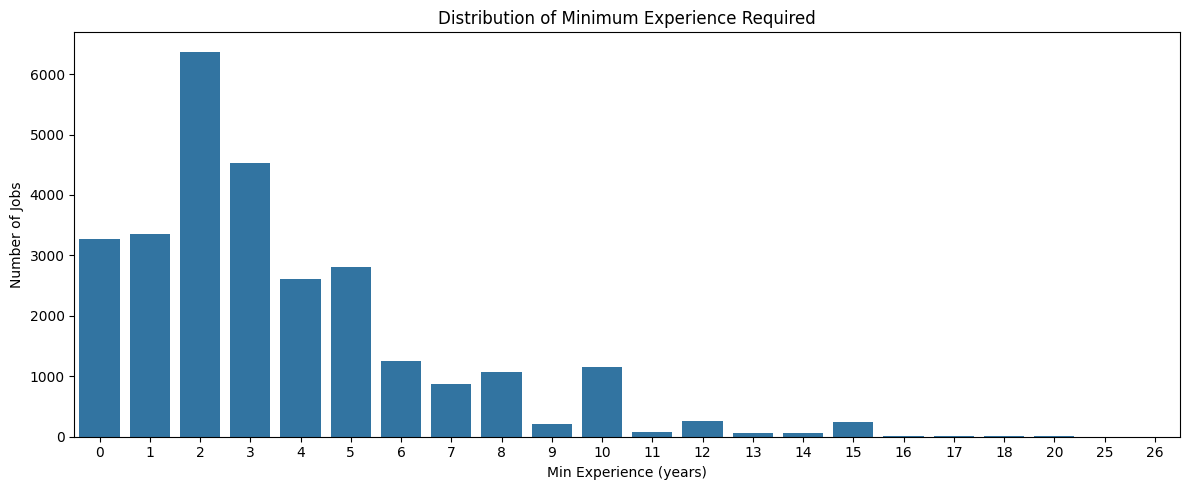

In [33]:

import seaborn as sb
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sb.countplot(data=df, x='Min Experience', order=sorted(df['Min Experience'].unique()))
plt.title('Distribution of Minimum Experience Required')
plt.xlabel('Min Experience (years)')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()

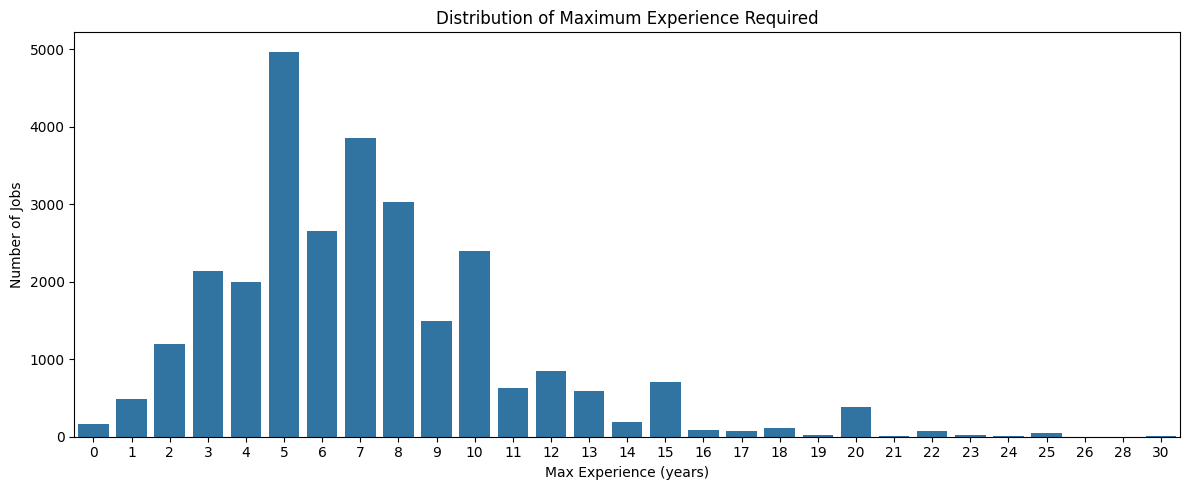

In [34]:
import seaborn as sb
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sb.countplot(data=df, x='Max Experience', order=sorted(df['Max Experience'].unique()))
plt.title('Distribution of Maximum Experience Required')
plt.xlabel('Max Experience (years)')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()

## Cleaning education

In [35]:
df['education']

0        UG: B.Tech/B.E. - Any Specialization PG:Any Po...
2        UG: Any Graduate - Any Specialization PG:Any P...
3        UG: Any Graduate - Any Specialization PG:CA Do...
3        UG: Any Graduate - Any Specialization PG:CA Do...
3        UG: Any Graduate - Any Specialization PG:CA Do...
                               ...                        
21996    UG: B.Tech/B.E. - Any Specialization PG:M.Tech...
21997    UG: B.Tech/B.E. - Any Specialization PG:Any Po...
21998    UG: B.Tech/B.E. - Any Specialization PG:MCA - ...
21998    UG: B.Tech/B.E. - Any Specialization PG:MCA - ...
21999    UG: B.Tech/B.E. - Any Specialization PG:MCA - ...
Name: education, Length: 28234, dtype: object

In [36]:
df['education'].isnull().sum()

np.int64(0)

In [37]:
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['education'].isnull().sum()


np.int64(0)

In [38]:
# Step 1: Now safely split without worrying about NaN
# EXPLANATION: No NaN exists now so x[0] will never crash
df['education'] = df['education'].str.split(' - ').apply(lambda x: x[0])

print("After splitting:")
print("Null count:", df['education'].isnull().sum())
print("Unique values:", df['education'].nunique())
df['education'].value_counts()

After splitting:
Null count: 0
Unique values: 238


education
UG: Any Graduate                                                                                                                                                                             10964
UG: Any Graduate PG:MBA/PGDM Doctorate:Any Doctorate                                                                                                                                          2597
UG: B.Tech/B.E. PG:Post Graduation Not Required Doctorate:Any Doctorate                                                                                                                       2380
UG: B.Tech/B.E. PG:M.Tech Doctorate:Any Doctorate                                                                                                                                             2333
UG: B.Tech/B.E.                                                                                                                                                                               1890
UG: Any Graduat

In [39]:
# Step 1: Remove 'UG: ' prefix and keep only UG degree part (before PG: or Doctorate:)
df['education'] = df['education'].str.replace('UG: ', '', regex=False)
df['education'] = df['education'].apply(lambda x: str(x).split(' PG:')[0].split(' Doctorate:')[0].strip() if pd.notna(x) else x)

# Step 2: Keep only first degree if multiple listed
df['education'] = df['education'].apply(lambda x: str(x).split(',')[0].strip() if pd.notna(x) else x)

In [40]:
# EXPLANATION: Now map messy degree names to clean standard labels
edu_map = {
    'B.Tech/B.E.': 'B.Tech',
    'Any Graduate': 'Any Graduate',
    'Graduation Not Required': 'Graduation Not Required',
    'B.Com': 'B.Com',
    'B.Sc': 'B.Sc',
    'B.A': 'B.A',
    'BCA': 'BCA',
    'B.B.A': 'BBA',
    'B.B.A / B.M.S': 'BBA',
    'Diploma': 'Diploma',
    'MBBS': 'MBBS',
    'B.Pharma': 'B.Pharma',
    'B.Ed': 'B.Ed',
    'LLB': 'LLB',
    'BHM': 'BHM',
    'BDS': 'BDS',
    'B.Arch': 'B.Arch',
    'Other Graduate': 'Other',
    'nan': 'Other',
}

df['education'] = df['education'].replace(edu_map)

# Fill remaining unmapped values with mode
df['education'] = df['education'].fillna(df['education'].mode()[0])

print("Final education value counts:")
df['education'].value_counts()

Final education value counts:


education
Any Graduate                        17471
B.Tech                               7972
B.Com                                 544
B.Sc                                  410
Diploma                               367
BBA                                   260
B.A                                   232
Graduation Not Required               186
BCA                                   172
MBBS                                  121
B.Ed                                   86
B.Pharma                               70
LLB                                    61
Doctorate:Any Doctorate                49
Doctorate:Doctorate Not Required       48
Other                                  47
BHM                                    39
PG:MBA/PGDM                            33
B.Arch                                 22
BDS                                    10
PG:Other                                9
PG:Any Postgraduate                     7
PG:CA                                   5
PG:MS/M.Sc(Science)     

## Cleaning industry

In [41]:
df['industry']

0              Media / Entertainment / Internet
2               IT-Software / Software Services
3        Banking / Financial Services / Broking
3        Banking / Financial Services / Broking
3        Banking / Financial Services / Broking
                          ...                  
21996           IT-Software / Software Services
21997                      Internet / Ecommerce
21998           IT-Software / Software Services
21998           IT-Software / Software Services
21999           IT-Software / Software Services
Name: industry, Length: 28234, dtype: object

In [42]:
df['industry'].value_counts()

industry
IT-Software / Software Services                               12498
Banking / Financial Services / Broking                         1729
Education / Teaching / Training                                1543
Recruitment / Staffing                                         1376
BPO / Call Centre / ITES                                       1228
Internet / Ecommerce                                            876
Pharma / Biotech / Clinical Research                            709
Construction / Engineering / Cement / Metals                    646
Automobile / Auto Anciliary / Auto Components                   592
Strategy / Management Consulting Firms                          502
Industrial Products / Heavy Machinery                           479
Medical / Healthcare / Hospitals                                470
Travel / Hotels / Restaurants / Airlines / Railways             437
Other                                                           434
Accounting / Finance                   

In [43]:
df['industry'].isnull().sum()

np.int64(0)

In [44]:
df['industry'] = df['industry'].fillna(df['industry'].mode()[0])
df['industry'].isnull().sum()

np.int64(0)

In [45]:
df['industry'].value_counts(ascending=True)

industry
Leather                                                           1
Glass / Glassware                                                 1
Broadcasting                                                      1
Brewery / Distillery                                              2
Tyres                                                             4
Gems / Jewellery                                                  6
Office Equipment / Automation                                     7
Water Treatment / Waste Management                               10
Fertilizers / Pesticides                                         11
Heat Ventilation / Air Conditioning                              11
Medical Devices / Equipments                                     14
Food Processing                                                  19
Fresher / Trainee / Entry Level                                  20
Aviation / Aerospace Firms                                       21
Wellness / Fitness / Sports / Beauty   

In [46]:
df['industry'].str.split('/')

0              [Media ,  Entertainment ,  Internet]
2                [IT-Software ,  Software Services]
3        [Banking ,  Financial Services ,  Broking]
3        [Banking ,  Financial Services ,  Broking]
3        [Banking ,  Financial Services ,  Broking]
                            ...                    
21996            [IT-Software ,  Software Services]
21997                       [Internet ,  Ecommerce]
21998            [IT-Software ,  Software Services]
21998            [IT-Software ,  Software Services]
21999            [IT-Software ,  Software Services]
Name: industry, Length: 28234, dtype: object

In [47]:
df['industry'] = df['industry'].str.split(' / ').apply(lambda x: x[0])
df['industry'].value_counts()

industry
IT-Software                 12498
Banking                      1729
Education                    1543
Recruitment                  1376
BPO                          1228
Internet                      876
Pharma                        709
Construction                  646
Automobile                    592
Strategy                      502
Industrial Products           479
Medical                       470
Travel                        437
Other                         434
Accounting                    404
Media                         338
Advertising                   320
FMCG                          298
Retail                        276
Telecom/ISP /                 258
IT-Hardware & Networking      256
Oil and Gas                   255
Insurance                     230
Consumer Electronics          198
Real Estate                   191
Semiconductors                186
KPO                           130
Electricals                   128
Textiles                      122
NGO  

## Cleaning Skills

In [48]:
df['skills']

0                                         ITES
2        IT Software - Application Programming
3                                     Accounts
3                                     Accounts
3                                     Accounts
                         ...                  
21996    IT Software - Application Programming
21997    IT Software - Application Programming
21998    IT Software - Application Programming
21998    IT Software - Application Programming
21999         IT Software - System Programming
Name: skills, Length: 28234, dtype: object

In [49]:
df['skills'].value_counts(ascending=True)

skills
Shipping                                      3
Beauty/Fitness/Spa Services                   7
Packaging                                    12
IT Software - Mainframe                      16
IT Software - Middleware                     27
Defence Forces                               27
TV                                           28
Export                                       57
IT Software - Systems                        57
Fashion Designing                            60
Architecture                                 63
IT Software - Client/Server Programming      75
Top Management                               85
Travel                                       89
Legal                                        95
Strategy                                    125
IT Software - Telecom Software              157
Analytics & Business Intelligence           179
Executive Assistant                         180
Hotels                                      189
IT Software - System Programming 

In [50]:
df['skills'].isnull().sum()

np.int64(0)

In [51]:
df['skills'] = df['skills'].fillna(df['skills'].mode()[0])
df['skills'].isnull().sum()

np.int64(0)

In [52]:
df['skills'] = df['skills'].str.split(' - ')
df['skills'] = df['skills'].apply(lambda x: x[1] if len(x)>1 else x[0])
df['skills'].value_counts(ascending=True)

skills
Shipping                                3
Beauty/Fitness/Spa Services             7
Packaging                              12
Mainframe                              16
Middleware                             27
Defence Forces                         27
TV                                     28
Export                                 57
Systems                                57
Fashion Designing                      60
Architecture                           63
Client/Server Programming              75
Top Management                         85
Travel                                 89
Legal                                  95
Strategy                              125
Telecom Software                      157
Analytics & Business Intelligence     179
Executive Assistant                   180
Hotels                                189
System Programming                    210
Mobile                                224
Supply Chain                          234
IT Hardware                

## Check null values in dataset

In [53]:
df.isnull().sum()

company                0
education              0
experience             0
industry               0
jobdescription         0
jobid                  0
joblocation_address    0
jobtitle               0
numberofpositions      0
payrate                0
postdate               0
site_name              0
skills                 0
uniq_id                0
Min Experience         0
Max Experience         0
dtype: int64

In [54]:
df['numberofpositions'] = df['numberofpositions'].fillna(1)  
df['numberofpositions'] = df['numberofpositions'].astype('int')

In [55]:
df = df.dropna() 


In [56]:
df.isnull().sum()

company                0
education              0
experience             0
industry               0
jobdescription         0
jobid                  0
joblocation_address    0
jobtitle               0
numberofpositions      0
payrate                0
postdate               0
site_name              0
skills                 0
uniq_id                0
Min Experience         0
Max Experience         0
dtype: int64